In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import parcels

/tmp/ipykernel_1254480/2983398643.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
print(parcels.__version__)

3.1.3.dev2088


In [3]:
ds_fields = xr.open_zarr("../../elphe-hackathon_data/cmems_uovo_2001.zarr/")
ds_fields

<xarray.Dataset> Size: 71GB
Dimensions:    (time: 10, depth: 50, latitude: 2041, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    uo         (time, depth, latitude, longitude) float64 35GB dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 35GB dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    copernicusmarine_version:  2.4.1
    domain_name:               GL12
    ...                        ...
    northing:                  latitude
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574

In [4]:
fields = {"U": ds_fields["uo"], "V": ds_fields["vo"]}
ds_fset = parcels.convert.copernicusmarine_to_sgrid(fields=fields)
ds_fset = ds_fset.fillna(0.0)
ds_fset = ds_fset.isel(depth=slice(0, 2))
fieldset = parcels.FieldSet.from_sgrid_conventions(ds_fset)
print(fieldset)

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <function XLinear at 0x1553bbb8fe20>
                time_interval   : TimeInterval(left=np.datetime64('2001-01-01T00:00:00.000000000'), right=np.datetime64('2001-01-10T00:00:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.DataArray 'U' (time: 10, depth: 2, lat: 2041, lon: 4320)> Size: 1GB
                dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
                Coordinates:
                  * time     (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
                  * depth    (depth) float32 8B 0.494 1.541
                  * lat      (lat) float32 8kB -80.0 -79.92 -79.83 -79.75 ... 89.83 89.92 90.0
                  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.8 179.9
                Attributes:
                    cell_methods:   area:

In [5]:
n_particles = 100_000

lon = np.random.uniform(-80, 20, size=(n_particles, ))
lat = np.random.uniform(-35, 40, size=(n_particles, ))
z = np.full_like(lon, ds_fields.depth.values[0])  # surface
time = np.array([ds_fields.time.values[0] for _ in range(n_particles)])  # initial time of the input data

pset = parcels.ParticleSet(
    fieldset=fieldset.to_windowed_arrays(max_levels=2), 
    # fieldset=fieldset,
    pclass=parcels.Particle, 
    time=time, 
    z=z,
    lat=lat,
    lon=lon,
)
print(pset)

<ParticleSet>
    Number of particles: 100000
    Particles:
        P[0]: time=0.000000, z=0.494025, lat=17.317450, lon=-27.033587, particle_id=0.000000
        P[1]: time=0.000000, z=0.494025, lat=-8.638545, lon=-59.455963, particle_id=1.000000
        P[2]: time=0.000000, z=0.494025, lat=-8.114918, lon=-23.800673, particle_id=2.000000
        P[3]: time=0.000000, z=0.494025, lat=-6.951581, lon=12.681189, particle_id=3.000000
        P[4]: time=0.000000, z=0.494025, lat=-17.723507, lon=-62.948502, particle_id=4.000000
        P[5]: time=0.000000, z=0.494025, lat=-0.265019, lon=-7.348063, particle_id=5.000000
        P[6]: time=0.000000, z=0.494025, lat=39.416668, lon=-53.657257, particle_id=6.000000
        ...
        P[99999]: time=0.000000, z=0.494025, lat=-17.968748, lon=-31.000875, particle_id=99999.000000
    Pclass:
        Variable(name='lon', dtype=dtype('float32'), initial=0, to_write=True, attrs={'standard_name': 'longitude', 'units': 'degrees_east', 'axis': 'X'})
        

In [6]:
kernels = [parcels.kernels.AdvectionRK4]

In [7]:
output_file = parcels.ParticleFile(
    "02_trajectories.parquet", outputdt=np.timedelta64(6, "h"), mode="w"
)

In [8]:
pset.execute(
    kernels,
    runtime=np.timedelta64(9, "D"),
    dt=np.timedelta64(2, "h"),
    output_file=output_file,
)

INFO: Output files are stored in 02_trajectories.parquet
Integration time: 2001-01-09T18:00:00 100%|██████████| [02:30<00:00, 5176.82it/s]


In [9]:
df = parcels.read_particlefile("02_trajectories.parquet")
df

lon,lat,z,time,particle_id
f32,f32,f32,datetime[ns],i64
-27.033587,17.31745,0.494025,2001-01-01 00:00:00,0
-59.455963,-8.638545,0.494025,2001-01-01 00:00:00,1
-23.800673,-8.114918,0.494025,2001-01-01 00:00:00,2
12.681189,-6.951581,0.494025,2001-01-01 00:00:00,3
-62.948502,-17.723507,0.494025,2001-01-01 00:00:00,4
…,…,…,…,…
-56.39579,35.017193,0.494025,2001-01-10 00:00:00,99995
-59.063339,3.055857,0.494025,2001-01-10 00:00:00,99996
-68.504326,3.307805,0.494025,2001-01-10 00:00:00,99997


/tmp/ipykernel_1254480/444948562.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


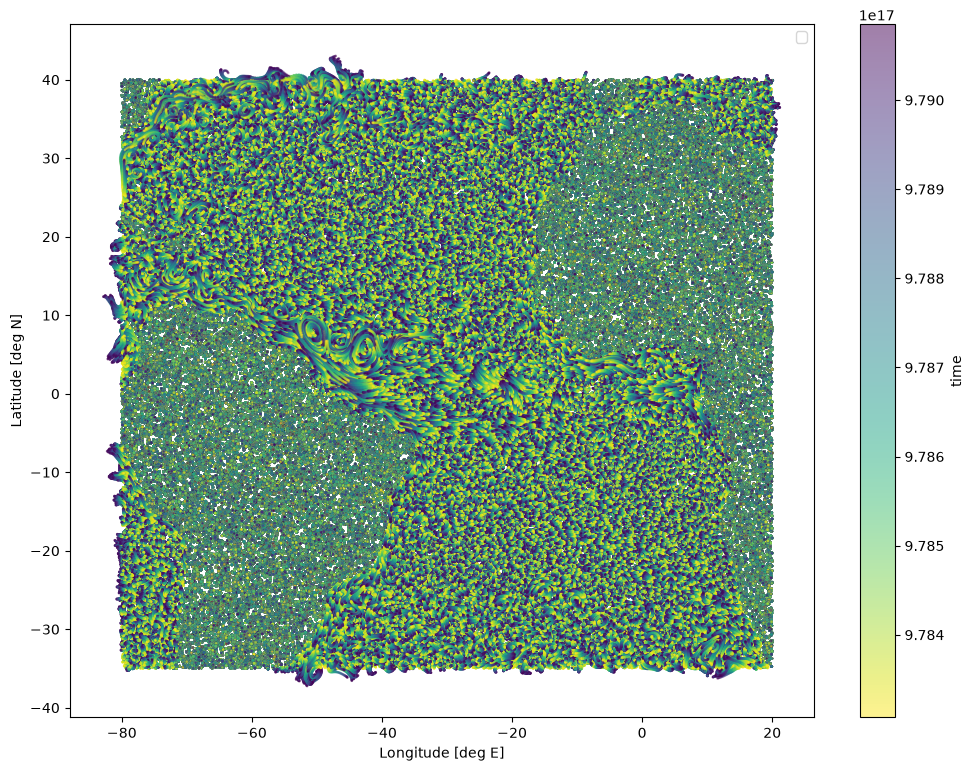

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
_df = df.to_pandas().sort_values("particle_id").set_index("particle_id").loc[range(0, 100_000, 1)]
scatter = ax.scatter(_df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r")
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.legend(loc="upper right")
fig.colorbar(scatter, ax=ax, label="time")
plt.show()